# Eje 4c — Market Data BYMA: paneles y opciones

Derivados Financieros — QUANt UCEMA

Paso a paso del mercado argentino: mismos módulos que la página **Market Data → BYMA** (`Codigo.data.byma_market`).

| Notebook | Contenido |
|----------|-----------|
| **04a** | Spot / quote / cadena **NYSE–US** (`market_data`) |
| **04b** | Lectura del panel: **IV ATM** y descriptivos |
| **04c** (este) | **BYMA**: spot ARS, histórico, panel de opciones |

**Fuentes (en orden):**
1. [data912.com](https://data912.com) — `/live/arg_stocks`, `/live/arg_options` (bid/ask/last, ~450 series)
2. `open.bymadata.com.ar` — paneles oficiales (fallback; fuera de rueda suele venir vacío)

**Plan:**
1. Setup
2. Spot y quote (GGAL)
3. Histórico de precios
4. Cómo se leen los tickers de opciones BYMA
5. Vencimientos y cadena
6. Mid, spread y ATM (como en la app)
7. (Opcional) Panel líderes vía API BYMA

## 1) Setup

Correr desde la raíz del repo o con el path al proyecto.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "Codigo" / "data" / "byma_market.py").exists():
        sys.path.insert(0, str(p))
        break

import pandas as pd
import Codigo.data.byma_market as bm

TICKER = "GGAL"  # también: YPFD, PAMP, ALUA, CEPU
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
print("OK — módulo:", bm.__file__)

OK — módulo: C:\Users\manue\OneDrive\Documents\finanzasCuantitativas\Codigo\data\byma_market.py


## 2) Spot y quote en ARS

`get_spot` / `get_quote` usan **data912** primero (`/live/arg_stocks` o `/live/arg_cedears`).
Si el panel viene en cero (finde), caen al último cierre histórico.

In [2]:
spot = bm.get_spot(TICKER)
quote = bm.get_quote(TICKER)
print(f"{TICKER} spot = {spot:.2f} ARS")
print(f"fuente spot: {getattr(bm.get_spot, 'last_source', None)}")
print({k: quote.get(k) for k in ('last', 'bid', 'ask', 'changePercent', 'source', 'currency', 'volume')})

GGAL spot = 6680.00 ARS
fuente spot: data912/live/arg_stocks
{'last': 6680.0, 'bid': 6680.0, 'ask': 6685.0, 'changePercent': -1.76, 'source': 'data912/live/arg_stocks', 'currency': 'ARS', 'volume': 1504842.0}


## 3) Histórico

Primero data912 `/historical/stocks/{ticker}`; si falla, OHLCV de BYMA (`TICKER 24HS`).

90 barras — último cierre 6680.00


,Precio
date,
2026-09-14,6865.0
2026-09-15,6720.0
2026-09-16,6745.0
2026-09-17,6810.0
2026-09-18,6680.0


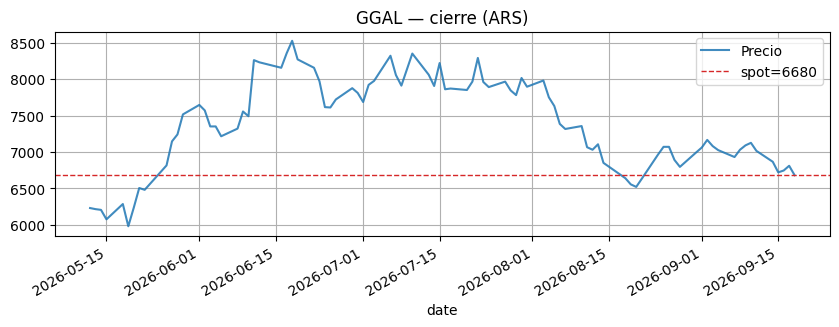

In [3]:
hist = bm.get_history(TICKER, days=90)
if hist is None or hist.empty:
    print("Sin histórico")
else:
    print(f"{len(hist)} barras — último cierre {hist['Precio'].iloc[-1]:.2f}")
    display(hist.tail())
    ax = hist["Precio"].plot(figsize=(10, 3), title=f"{TICKER} — cierre (ARS)", grid=True, alpha=0.85)
    ax.axhline(spot, color="C3", ls="--", lw=1, label=f"spot={spot:.0f}")
    ax.legend()

## 4) Tickers de opciones BYMA

Formato típico: `{RAÍZ}{C|V}{STRIKE}{MES}`

| Ejemplo | Lectura |
|---------|---------|
| `GFGC4600OC` | raíz **GFG** (= GGAL), **C**all, strike **4600**, mes **OC** (octubre) |
| `GFGV5000DI` | Put, strike 5000, diciembre |
| `ALUC700.OC` | ALUA call 700 (a veces con punto) |

El conversor del curso está en `Codigo.utils.opciones_byma.conversor_ticker` (GFG→GGAL, YPF→YPFD, …).

In [4]:
from Codigo.utils.opciones_byma import conversor_ticker

ejemplos = ["GFGC4600OC", "GFGV5000DI", "ALUC1000DI", "YPFC70000OC", "CEPC2036DI"]
for sym in ejemplos:
    parsed = bm._parse_option_symbol(sym)
    print(f"{sym:14s} → {parsed}")

print("\nRaíces que mapean a", TICKER, "→", sorted(bm._roots_for_underlying(TICKER)))
print("conversor_ticker('GFG') =", conversor_ticker("GFG"))

GFGC4600OC     → {'root': 'GFG', 'underlying': 'GGAL', 'type': 'call', 'strike': 4600.0, 'expiration': '2026-10-16', 'month_code': 'OC'}
GFGV5000DI     → {'root': 'GFG', 'underlying': 'GGAL', 'type': 'put', 'strike': 5000.0, 'expiration': '2026-12-18', 'month_code': 'DI'}
ALUC1000DI     → {'root': 'ALU', 'underlying': 'ALUA', 'type': 'call', 'strike': 1000.0, 'expiration': '2026-12-18', 'month_code': 'DI'}
YPFC70000OC    → {'root': 'YPF', 'underlying': 'YPFD', 'type': 'call', 'strike': 70000.0, 'expiration': '2026-10-16', 'month_code': 'OC'}
CEPC2036DI     → {'root': 'CEP', 'underlying': 'CEPU', 'type': 'call', 'strike': 2036.0, 'expiration': '2026-12-18', 'month_code': 'DI'}

Raíces que mapean a GGAL → ['GFG', 'GGA', 'GGAL']
conversor_ticker('GFG') = GGAL


## 5) Panel de opciones → vencimientos → cadena

Misma secuencia que la app: `get_expirations` → elegir un vto → `get_options_chain`.

Fuente preferida: **data912** `/live/arg_options` (no Yahoo).

In [5]:
exps = bm.get_expirations(TICKER)
print(f"Vencimientos ({len(exps)}):", exps)
print("Fuente panel:", bm.get_options_source())

if not exps:
    raise SystemExit("Sin vencimientos — revisar red / data912")

expiry = exps[0]
chain = bm.get_options_chain(TICKER, expiry)
print(f"\nCadena {TICKER} @ {expiry}: {len(chain)} contratos  (fuente: {getattr(bm.get_options_chain, 'last_source', None)})")
print(chain.groupby("type").size().to_dict())
display(chain.sort_values(["type", "strike"]).head(12))

Vencimientos (3):

 ['2026-10-16', '2026-12-18', '2027-09-18']
Fuente panel: data912/arg_options



Cadena GGAL @ 2026-10-16: 58 contratos  (fuente: data912/arg_options)
{'call': 29, 'put': 29}


,contractSymbol,strike,type,expiration,bid,ask,lastPrice,volume,openInterest,impliedVolatility,Spot,Ticker,source
3,GFGC4200OC,4200.0,call,2026-10-16,2527.796,2576.206,2547.293,3.0,2.0,NaN,6680.0,GGAL,data912
4,GFGC4400OC,4400.0,call,2026-10-16,2331.672,2379.545,2351.011,8.0,3.0,NaN,6680.0,GGAL,data912
5,GFGC4600OC,4600.0,call,2026-10-16,2135.719,2183.428,2155.777,4.0,2.0,NaN,6680.0,GGAL,data912
6,GFGC4800OC,4800.0,call,2026-10-16,1939.987,1987.128,2084.205,0.0,26.0,NaN,6680.0,GGAL,data912
7,GFGC5000OC,5000.0,call,2026-10-16,1744.440,1791.473,1765.203,23.0,8.0,NaN,6680.0,GGAL,data912
8,GFGC5200OC,5200.0,call,2026-10-16,1550.087,2100.000,1569.042,59.0,16.0,NaN,6680.0,GGAL,data912
9,GFGC5400OC,5400.0,call,2026-10-16,1355.000,1404.283,1397.000,25.0,7.0,NaN,6680.0,GGAL,data912
10,GFGC5600OC,5600.0,call,2026-10-16,1166.401,1213.136,1213.136,175.0,40.0,NaN,6680.0,GGAL,data912
11,GFGC5800OC,5800.0,call,2026-10-16,974.830,1040.630,1100.000,0.0,0.0,NaN,6680.0,GGAL,data912
12,GFGC6000OC,6000.0,call,2026-10-16,800.200,869.503,875.959,47.0,14.0,NaN,6680.0,GGAL,data912


## 6) Mid, spread y ATM

Igual criterio que 04a / la webapp: mid = (bid+ask)/2 cuando hay ambos lados.

In [6]:
df = chain.copy()
bid = pd.to_numeric(df["bid"], errors="coerce")
ask = pd.to_numeric(df["ask"], errors="coerce")
df["mid"] = ((bid + ask) / 2).where(bid.notna() & ask.notna())
df["spread"] = (ask - bid).where(bid.notna() & ask.notna())
df["moneyness"] = df["strike"] / spot

atm_idx = (df["strike"] - spot).abs().idxmin()
atm = df.loc[atm_idx]
print(f"Spot={spot:.2f}  ATM strike={atm['strike']:.0f}  type={atm['type']}  mid={atm.get('mid')}")

near = df[(df["moneyness"] > 0.85) & (df["moneyness"] < 1.15)].sort_values("strike")
cols = [c for c in ["contractSymbol", "type", "strike", "bid", "ask", "mid", "spread", "lastPrice", "volume", "moneyness"] if c in near.columns]
display(near[cols].head(20))

Spot=6680.00  ATM strike=6600  type=call  mid=422.0


,contractSymbol,type,strike,bid,ask,mid,spread,lastPrice,volume,moneyness
11,GFGC5800OC,call,5800.0,974.830,1040.630,1007.7300,65.800,1100.000,0.0,0.868263
40,GFGV5800OC,put,5800.0,27.500,28.990,28.2450,1.490,29.670,4315.0,0.868263
41,GFGV6000OC,put,6000.0,53.061,55.340,54.2005,2.279,54.000,5802.0,0.898204
12,GFGC6000OC,call,6000.0,800.200,869.503,834.8515,69.303,875.959,47.0,0.898204
13,GFGC6200OC,call,6200.0,668.000,710.000,689.0000,42.000,701.000,481.0,0.928144
42,GFGV6200OC,put,6200.0,91.000,92.690,91.8450,1.690,91.000,6086.0,0.928144
43,GFGV6400OC,put,6400.0,146.524,151.870,149.1970,5.346,146.524,8674.0,0.958084
14,GFGC6400OC,call,6400.0,542.010,562.990,552.5000,20.980,542.000,546.0,0.958084
44,GFGV6600OC,put,6600.0,209.010,227.870,218.4400,18.860,222.000,7268.0,0.988024
15,GFGC6600OC,call,6600.0,418.000,426.000,422.0000,8.000,420.000,3417.0,0.988024


## 7) (Opcional) Panel líderes — API oficial BYMA

Útil para ver el snapshot CI/24hs. Fuera de horario muchos campos vienen en 0; por eso el spot de la app prioriza data912.

In [7]:
try:
    lideres = bm.fetch_panel("leading-equity", t1=True, fetch_all=True)
    print(f"Ítems líderes 24hs: {len(lideres)}")
    row = next((x for x in lideres if str(x.get("symbol", "")).upper() == TICKER), None)
    if row:
        keys = ["symbol", "trade", "closingPrice", "bidPrice", "offerPrice", "volumeAmount", "settlementType"]
        print({k: row.get(k) for k in keys})
    else:
        print(f"{TICKER} no está en el recorte de líderes (o panel vacío).")
except Exception as e:
    print("Panel BYMA no disponible:", e)

Ítems líderes 24hs: 21
{'symbol': 'GGAL', 'trade': 0.0, 'closingPrice': 0.0, 'bidPrice': 0.0, 'offerPrice': 0.0, 'volumeAmount': 0.0, 'settlementType': '2'}


## Resumen

- **04a** = US (Yahoo / `market_data`). **04c** = Argentina (data912 + BYMA).
- Opciones locales: parsear raíz/C|V/strike/mes; GFG = GGAL.
- En la app: Market Data → **BYMA** → ticker → Cargar → vencimiento → Cargar opciones.
- **Ejercicio:** compará el spread bid–ask ATM de GGAL vs otro subyacente del panel (YPFD, PAMP, CEPU).
- **Siguiente:** 04b (IV sobre cadena US) o Eje 5 con precios reales en *Market Data Pricing*.